<br/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="left"/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science - Módulo 4</h2><br/>
<h1>Transfer Learning y Fine Tuning</h1>
<br/><br/>
    <b>Instructor Principal:</b> Patricio Olivares polivares@skillnest.com <br/>
    <b>Instructor Asistente:</b> Cristian Sánchez csanchez@skillnest.com<br/><br/>
    <b>Skill Nest</b>
</div>
<br>

# 1. Introducción al Transfer Learning

## ¿Qué es Transfer Learning?
- Es una técnica que permite reutilizar el conocimiento aprendido por un modelo al resolver una tarea anterior para aplicarlo en una nueva tarea relacionada.
- En lugar de entrenar una red neuronal **desde cero**, aprovechamos los pesos aprendidos de un modelo grande y general.


**Analogía práctica**
- Imagina que sabes conducir un auto con transmisión manual.
- Aprender a manejar una camioneta manual es mucho más rápido porque ya dominas el uso de los pedales y la palanca de cambios.
- Solo necesitas adaptarte a detalles nuevos como el tamaño y el radio de giro.
- Del mismo modo, en Transfer Learning usamos el "saber conducir" de un modelo para enfrentar una tarea similar con menos esfuerzo.

**Utilidad**
- Permite entrenar modelos robustos cuando se dispone de pocos datos.
- Ahorra tiempo de cómputo y recursos.
- Logra mejores resultados iniciales porque parte de una base sólida.
- Es especialmente útil en problemas donde hay similitudes con el dataset original del modelo pre-entrenado.

## Beneficios clave

- Reduce la cantidad de datos necesarios para obtener buenos resultados.
- Disminuye los tiempos de entrenamiento.
- Mejora el rendimiento del modelo.
- Fomenta la reutilización de modelos robustos y bien validados.

## Caso práctico motivador

- Un ejemplo real es la detección de neumonía en radiografías de tórax.
- Los hospitales suelen tener datasets limitados de radiografías etiquetadas por especialistas.
- Entrenar una CNN desde cero requiere millones de imágenes, lo cual no es viable.
- Al usar Transfer Learning con un modelo pre-entrenado en ImageNet, se aprovecha el conocimiento aprendido para detectar bordes, texturas y estructuras generales.
- Esto permite enfocar el entrenamiento solo en ajustar el modelo para reconocer patrones específicos de neumonía en los pulmones.

## Limitaciones

- Transfer Learning no siempre es útil si la tarea nueva es demasiado distinta de la original.
- Es importante entender qué parte del conocimiento es transferible y qué parte debe ajustarse.

# 2. Transfer Learning en `TensorFlow`

## ¿Cómo se implementa?

- `TensorFlow` y `Keras` facilitan usar Transfer Learning con modelos pre-entrenados disponibles en `keras.applications`.
- Los pasos generales son:
  - Cargar un modelo pre-entrenado con pesos aprendidos de un gran dataset (por ejemplo, [ImageNet](https://www.image-net.org/)).
  - Eliminar la parte superior (la capa de clasificación original) para poder usar la red como extractor de características.
  - Congelar la base convolucional para evitar actualizar sus pesos durante la primera etapa.
  - Añadir una nueva cabeza (clasificador) ajustada a la nueva tarea.
  - Entrenar solo la cabeza primero. Posteriormente se puede realizar Fine Tuning.

## ¿Qué es ImageNet?

- ImageNet es un dataset de imágenes organizado jerárquicamente siguiendo la estructura de WordNet.
- Contiene más de 14 millones de imágenes anotadas de forma manual y categorizadas en más de 21,000 clases no vacías.
- Desde 2010, se ha usado como base para el desafío ILSVRC (ImageNet Large Scale Visual Recognition Challenge), que es un punto de referencia para clasificación y detección de objetos.
- Las anotaciones pueden ser de dos tipos:
  - Etiquetas de nivel de imagen: presencia o ausencia de una clase de objeto (por ejemplo, “hay autos en esta imagen”).
  - Anotaciones de objetos: cajas delimitadoras con etiquetas de clase para cada instancia de objeto en la imagen.
- El proyecto ImageNet no posee los derechos de autor de las imágenes, solo se proporcionan miniaturas y URLs de las imágenes originales.
- Es uno de los datasets más usados para preentrenar modelos de visión por computadora por su tamaño y variedad.


## Modelos disponibles en `keras.applications`

- TensorFlow provee varios modelos listos para Transfer Learning, todos basados en redes convolucionales entrenadas con el dataset ImageNet.
- Algunos de los más usados son:
  - **ResNet**: redes profundas con conexiones residuales que facilitan el entrenamiento de muchas capas.
  - **VGG**: arquitectura simple con capas convolucionales y de pooling apiladas de forma secuencial.
  - **Inception**: usa módulos que combinan convoluciones de diferentes tamaños para capturar patrones variados.
  - **Xception**: variante de Inception basada en separable convolutions para mayor eficiencia.
  - **MobileNet**: diseñado para dispositivos móviles y de recursos limitados, con menor peso y buena precisión.
  - **DenseNet**: cada capa recibe información de todas las capas anteriores, mejorando la reutilización de características.
  - **EfficientNet**: combina precisión y eficiencia ajustando profundidad, anchura y resolución de forma equilibrada.

- Estos modelos se usan principalmente para tareas de clasificación de imágenes, pero pueden adaptarse para detección de objetos y segmentación modificando la parte superior del modelo.

## Factores para elegir un modelo

- Tamaño de la entrada: cada modelo tiene un tamaño mínimo de imagen recomendado (por ejemplo: ResNet50 usa 224x224).
- Complejidad y precisión: modelos más grandes suelen ofrecer mayor precisión pero requieren más recursos.
- Velocidad: MobileNet y EfficientNet son modelos optimizados para dispositivos con recursos limitados.
- Disponibilidad de pesos pre-entrenados: es clave usar modelos entrenados con datasets grandes y bien conocidos como ImageNet.

## Consideraciones prácticas

- Usar `include_top=False` permite eliminar la parte superior y conectar un clasificador propio.
- Congelar la base convolucional evita destruir el conocimiento general adquirido.
- Ajustar la nueva cabeza permite adaptar el modelo a la nueva tarea.
- En muchos casos, se entrena solo la cabeza y luego se realiza Fine Tuning para refinar capas específicas.

## Referencia útil
- Documentación oficial de modelos pre-entrenados:
  - https://www.tensorflow.org/api_docs/python/tf/keras/applications

# 3. Ejemplo práctico con Transfer Learning y CIFAR-10

## Preparación de librerías y datos

- Importar TensorFlow, Keras y librerías necesarias.
- Cargar el dataset CIFAR-10.
- Normalizar las imágenes a valores flotantes.
- Convertir etiquetas a one-hot encoding.

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# One-hot encoding
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Datos preparados.")

Datos preparados.


## Cargar modelo pre-entrenado

- Usaremos EfficientNetV2B0 con pesos de ImageNet.
- Se elimina la parte superior (`include_top=False`).
- Se ajusta el `input_shape` para las imágenes de CIFAR-10.

In [ ]:
INPUT_SHAPE = (32, 32, 3)

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE
)

print("Modelo base cargado.")


I0000 00:00:1752008576.201738  206315 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22336 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:05:00.0, compute capability: 8.6
I0000 00:00:1752008576.203171  206315 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4149 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Modelo base cargado.


## Congelar la base convolucional

- Para extracción de características, la base del modelo se congela.
- Solo se entrenará la cabeza del modelo.

In [ ]:
base_model.trainable = False
print("Base congelada.")

Base congelada.


## Construir la nueva cabeza
- Se arma un modelo `Sequential`:
    - Base convolucional.
    - Capa de pooling global.
    - Capa de Dropout para regularización.
    - Capa `Dense` final para clasificación.

In [ ]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1, 1, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Compilar y entrenar

- Usar Adam como optimizador.
- Pérdida: CategoricalCrossentropy.
- Métrica: Accuracy.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train_cat,
    epochs=100,
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stop]
)

Epoch 1/100


I0000 00:00:1752008594.107133  206418 service.cc:152] XLA service 0x76aa5c0048e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752008594.107150  206418 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1752008594.107152  206418 service.cc:160]   StreamExecutor device (1): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-07-08 17:03:14.400969: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752008595.900435  206418 cuda_dnn.cc:529] Loaded cuDNN version 90300


  17/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.1159 - loss: 2.3398   

I0000 00:00:1752008604.005433  206418 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.4072 - loss: 1.7349 - val_accuracy: 0.5695 - val_loss: 1.2573
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5480 - loss: 1.3225 - val_accuracy: 0.5981 - val_loss: 1.1795
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5654 - loss: 1.2617 - val_accuracy: 0.6041 - val_loss: 1.1410
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5614 - loss: 1.2588 - val_accuracy: 0.6096 - val_loss: 1.1361
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5750 - loss: 1.2297 - val_accuracy: 0.6154 - val_loss: 1.1126
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5734 - loss: 1.2274 - val_accuracy: 0.6183 - val_loss: 1.1045
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5818 - loss: 1.2122 - val_accuracy: 0.6217 - val_loss: 1.0964
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5758 - loss: 1.2211 - 

## Evaluar resultados

- Evaluar precisión final en conjunto de prueba.
- Graficar accuracy y loss para analizar entrenamiento.

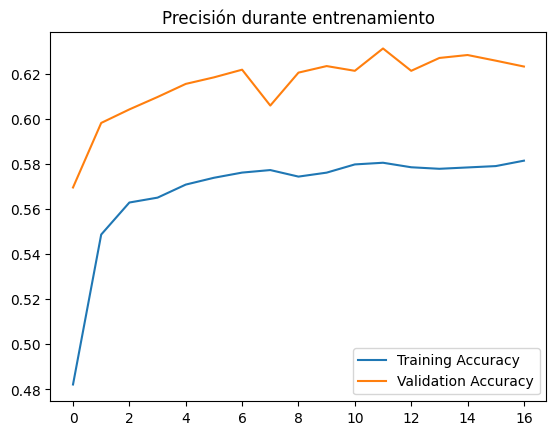

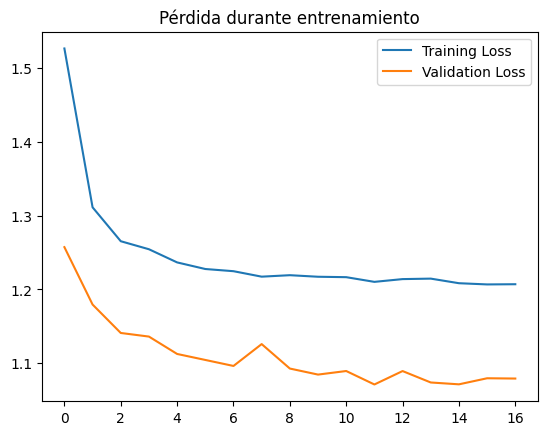

Precisión final en test: 63.11%


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Precisión durante entrenamiento")
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Pérdida durante entrenamiento")
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Precisión final en test: {test_acc:.2%}")


## Fine Tuning de capas intermedias

- Después de entrenar solo la cabeza, se puede mejorar el rendimiento descongelando algunas capas superiores de la base convolucional.
- Esto permite ajustar pesos de alto nivel a nuestro dataset específico.
- No se recomienda descongelar toda la base, ya que puede llevar a sobreajuste o tiempos de entrenamiento mucho mayores.

### Descongelar las últimas capas de la base

- Revisar cuántas capas tiene la base.
- Descongelar un bloque superior (por ejemplo, las últimas 20 capas).


In [ ]:
# Mostrar total de capas en la base
print(f"Número total de capas en la base: {len(base_model.layers)}")

# Descongelar últimas 20 capas
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Confirmar cuáles capas están entrenables
print(f"Número de capas entrenables en la base ahora:")
print(sum([layer.trainable for layer in base_model.layers]))

Número total de capas en la base: 270
Número de capas entrenables en la base ahora:
20


## Recompilar el modelo

- Después de cambiar el estado entrenable de las capas, siempre recompilar el modelo.
- Usar una tasa de aprendizaje más baja para evitar destruir pesos ya ajustados.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # LR más baja
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

## Entrenar nuevamente
- Entrenar unas pocas épocas para refinar pesos.
- Validar si hay mejora en la precisión.

In [ ]:
fine_tune_epochs = 100

history_fine = model.fit(
    x_train,
    y_train_cat,
    epochs=100,
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stop]
)


Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.1893 - loss: 8.2880 - val_accuracy: 0.5422 - val_loss: 1.5598
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4822 - loss: 1.9769 - val_accuracy: 0.6055 - val_loss: 1.2132
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5307 - loss: 1.5695 - val_accuracy: 0.6250 - val_loss: 1.1226
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5519 - loss: 1.4328 - val_accuracy: 0.6497 - val_loss: 1.0540
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5757 - loss: 1.3259 - val_accuracy: 0.6539 - val_loss: 1.0148
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5919 - loss: 1.2564 - val_accuracy: 0.6661 - val_loss: 0.9859
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6015 - loss: 1.2022 - val_accuracy: 0.6701 - val_loss: 0.9711
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6166 - los

## Evaluar después de Fine Tuning
- Comparar resultados antes y después.
- Analizar si se obtuvo mejora sin sobreajuste.

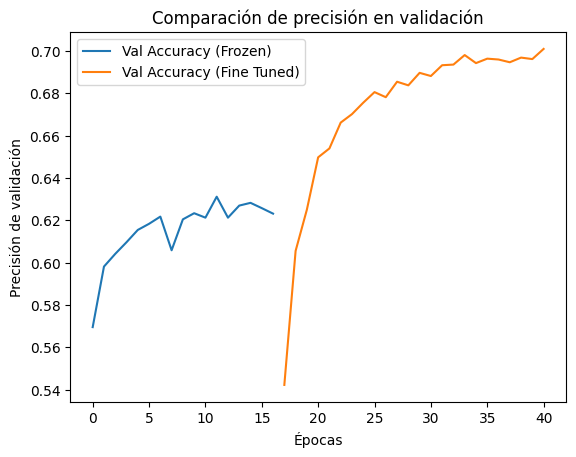

Precisión final después de Fine Tuning: 69.63%


In [ ]:
import matplotlib.pyplot as plt

# Longitud real de cada fase considerando early stopping
frozen_epochs = len(history.history['val_accuracy'])
fine_tune_epochs_actual = len(history_fine.history['val_accuracy'])

# Ejes de cada curva
plt.plot(
    range(frozen_epochs),
    history.history['val_accuracy'],
    label='Val Accuracy (Frozen)'
)
plt.plot(
    range(frozen_epochs, frozen_epochs + fine_tune_epochs_actual),
    history_fine.history['val_accuracy'],
    label='Val Accuracy (Fine Tuned)'
)

plt.legend()
plt.title("Comparación de precisión en validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión de validación")
plt.show()

final_loss, final_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Precisión final después de Fine Tuning: {final_acc:.2%}")



# 4. Fine Tuning

## ¿Qué es Fine Tuning?

- Fine Tuning es la segunda etapa del Transfer Learning.
- Después de entrenar solo la cabeza del modelo (clasificador), se descongela una parte de la base convolucional.
- Esto permite ajustar pesos de capas superiores para que se adapten mejor a la nueva tarea.
- Es útil cuando se tiene un dataset algo mayor y se busca un rendimiento extra.

## ¿Por qué no se descongela todo desde el inicio?

- Entrenar todo el modelo desde cero puede borrar el conocimiento general adquirido.
- Las capas iniciales detectan características muy genéricas como bordes y texturas.
- Descongelar solo capas intermedias o superiores permite refinar representaciones más específicas sin afectar lo básico.

## Buenas prácticas

- Descongelar pocas capas primero y probar resultados.
- Usar una tasa de aprendizaje más baja para evitar grandes cambios en los pesos.
- Monitorear la validación para detenerse si se observa sobreajuste.
- Usar callbacks como EarlyStopping para cortar entrenamiento innecesario.

# 5. Segundo ejemplo práctico: Transfer Learning y Fine Tuning con Xception

## Preparación

- Usaremos nuevamente el dataset CIFAR-10.
- Cambiaremos la base convolucional a Xception.
- Xception es un modelo eficiente que funciona bien con imágenes pequeñas y suele alcanzar alta precisión en CIFAR-10.
- Flujo general:
  - Redimensionar imágenes.
  - Cargar Xception pre-entrenado.
  - Congelar la base y entrenar la cabeza.
  - Descongelar capas superiores para Fine Tuning.

## Cargar y preparar CIFAR-10 (71x71)

In [36]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cargar dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Redimensionar a 71x71 y normalizar
IMG_SIZE = (71, 71)

x_train_resized = tf.image.resize(x_train, IMG_SIZE).numpy().astype("float32")
x_test_resized = tf.image.resize(x_test, IMG_SIZE).numpy().astype("float32")

# One-hot encoding
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Nuevo tamaño de imágenes: {x_train_resized.shape}")

Nuevo tamaño de imágenes: (50000, 71, 71, 3)


## Cargar Xception como base

In [37]:
INPUT_SHAPE = (71, 71, 3)

base_model_xception = keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE
)

base_model_xception.trainable = False

print(f"Xception base cargada con {len(base_model_xception.layers)} capas.")

Xception base cargada con 132 capas.


## Crear nuevo modelo con Xception

In [38]:
model_xception = keras.Sequential([
    base_model_xception,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model_xception.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 3, 3, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,881,970 (79.66 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Compilar y entrenar solo la cabeza

In [40]:
model_xception.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

history_xception = model_xception.fit(
    x_train_resized,
    y_train_cat,
    epochs=100,
    validation_data=(x_test_resized, y_test_cat),
    callbacks=[early_stop]
)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2164 - loss: 9.7434

2025-07-08 17:42:51.051711: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1056', 60 bytes spill stores, 60 bytes spill loads

2025-07-08 17:42:51.358593: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1056', 3884 bytes spill stores, 3860 bytes spill loads

2025-07-08 17:42:51.375607: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1056', 3620 bytes spill stores, 3612 bytes spill loads

2025-07-08 17:42:55.832309: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1056', 3620 bytes spill stores, 3612 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.2164 - loss: 9.7418 - val_accuracy: 0.3680 - val_loss: 3.3912
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.2902 - loss: 4.3854 - val_accuracy: 0.3365 - val_loss: 3.2200
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.2887 - loss: 4.1362 - val_accuracy: 0.2943 - val_loss: 3.8878
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.2921 - loss: 4.2147 - val_accuracy: 0.3285 - val_loss: 3.4264
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.2905 - loss: 4.2073 - val_accuracy: 0.3259 - val_loss: 3.5903
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.2952 - loss: 4.1768 - val_accuracy: 0.3233 - val_loss: 3.5754
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.2994 - loss: 4.0548 - val_accuracy: 0.3212 - val_loss: 3.4633


## Evaluar resultados (solo transfer learning)

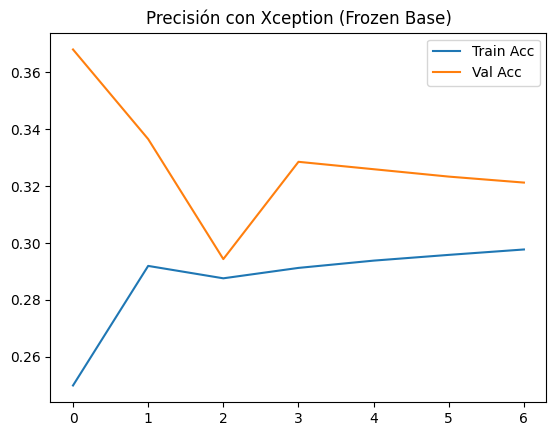

Precisión con Xception (Frozen Base): 33.65%


In [42]:
import matplotlib.pyplot as plt

plt.plot(history_xception.history['accuracy'], label='Train Acc')
plt.plot(history_xception.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Precisión con Xception (Frozen Base)")
plt.show()

loss, acc = model_xception.evaluate(x_test_resized, y_test_cat, verbose=0)
print(f"Precisión con Xception (Frozen Base): {acc:.2%}")


## Fine Tuning con Xception
- Descongelar las últimas 20 capas para refinar patrones específicos.
- Recompilar con una tasa de aprendizaje menor.
- Usar EarlyStopping para evitar sobreajuste.

In [43]:
print(f"Total de capas en Xception: {len(base_model_xception.layers)}")

for layer in base_model_xception.layers[-20:]:
    layer.trainable = True

print(f"Capas entrenables ahora: {sum([layer.trainable for layer in base_model_xception.layers])}")

model_xception.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

history_xception_fine = model_xception.fit(
    x_train_resized,
    y_train_cat,
    epochs=100,
    validation_data=(x_test_resized, y_test_cat),
    callbacks=[early_stop]
)


Total de capas en Xception: 132
Capas entrenables ahora: 20
Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.2446 - loss: 2.0921 - val_accuracy: 0.4048 - val_loss: 1.7081
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4079 - loss: 1.6966 - val_accuracy: 0.4648 - val_loss: 1.5089
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4631 - loss: 1.5249 - val_accuracy: 0.4926 - val_loss: 1.4125
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5007 - loss: 1.4232 - val_accuracy: 0.5161 - val_loss: 1.3569
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5245 - loss: 1.3466 - val_accuracy: 0.5355 - val_loss: 1.3007
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5476 - loss: 1.2834 - val_accuracy: 0.5557 - val_loss: 1.2480
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5690 - loss: 1.2228 - val_accuracy: 0.5635 - val_loss: 1.2279
Epoch 8/1

## Evaluar después de Fine Tuning

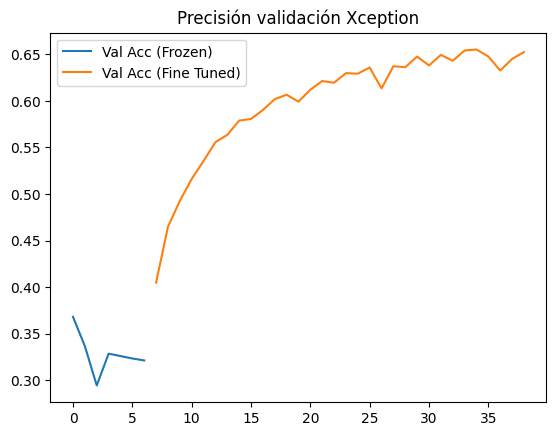

Precisión final con Xception después de Fine Tuning: 65.42%


In [45]:
# Comparar validación antes y después considerando EarlyStopping
frozen_epochs = len(history_xception.history['val_accuracy'])
fine_epochs = len(history_xception_fine.history['val_accuracy'])

plt.plot(range(frozen_epochs), history_xception.history['val_accuracy'], label='Val Acc (Frozen)')
plt.plot(range(frozen_epochs, frozen_epochs + fine_epochs), history_xception_fine.history['val_accuracy'], label='Val Acc (Fine Tuned)')
plt.legend()
plt.title("Precisión validación Xception")
plt.show()

loss, acc = model_xception.evaluate(x_test_resized, y_test_cat, verbose=0)
print(f"Precisión final con Xception después de Fine Tuning: {acc:.2%}")



- Transfer Learning permite reutilizar conocimiento de modelos grandes y bien entrenados para nuevas tareas.
- Congelar la base convolucional es la forma básica de usarla como extractor de características.
- Fine Tuning se aplica para ajustar capas superiores cuando se necesita un rendimiento mayor.
- Es recomendable usar una tasa de aprendizaje más baja y descongelar pocas capas al inicio.
- Siempre monitorear las métricas de validación para detectar sobreajuste.
- Comparar diferentes modelos ayuda a elegir la mejor opción según los datos y recursos disponibles.
